In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA


In [3]:
data = pd.read_csv("C:\Users\SHREYA\Downloads\archive (8)\Occupancy.csv")

data['timestamp'] = pd.to_datetime(data['timestamp'])
data.set_index('timestamp', inplace=True)

data.head()


SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (3129095432.py, line 1)

In [5]:
import pandas as pd

data = pd.read_csv(r"C:\Users\SHREYA\Downloads\archive (8)\Occupancy.csv")

data['timestamp'] = pd.to_datetime(data['timestamp'])
data.set_index('timestamp', inplace=True)

data.head()


KeyError: 'timestamp'

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA



In [13]:
data = pd.read_csv(r"C:\Users\SHREYA\Downloads\archive (8)\Occupancy.csv")

data.head()


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,2015-02-02 14:19:00,23.7000,26.272,585.200000,749.200000,0.004764,1
1,2015-02-02 14:19:59,23.7180,26.290,578.400000,760.400000,0.004773,1
2,2015-02-02 14:21:00,23.7300,26.230,572.666667,769.666667,0.004765,1
3,2015-02-02 14:22:00,23.7225,26.125,493.750000,774.750000,0.004744,1
4,2015-02-02 14:23:00,23.7540,26.200,488.600000,779.000000,0.004767,1


In [15]:
data.columns


Index(['date', 'Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio',
       'Occupancy'],
      dtype='object')

In [17]:
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)


In [32]:
data['electricity'] = data['Occupancy'] * 0.12  


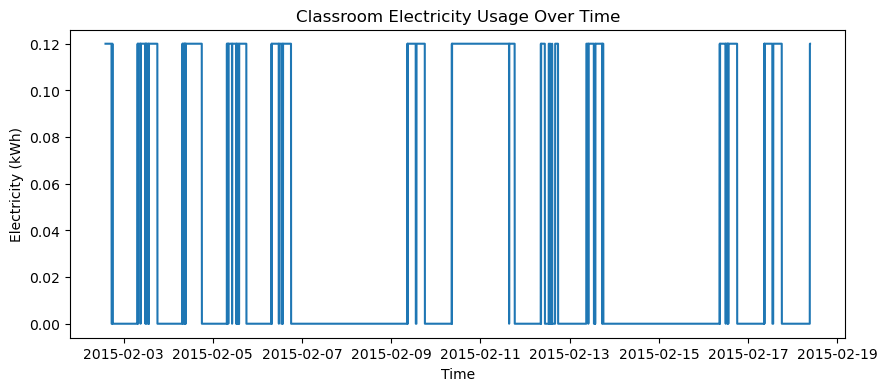

In [21]:
plt.figure(figsize=(10,4))
plt.plot(data['electricity'])
plt.title("Classroom Electricity Usage Over Time")
plt.xlabel("Time")
plt.ylabel("Electricity (kWh)")
plt.show()


In [23]:
model = ARIMA(data['electricity'], order=(1,1,1))
model_fit = model.fit()

model_fit.summary()


C:\Users\SHREYA\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\SHREYA\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\SHREYA\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            electricity   No. Observations:                20560
Model:                 ARIMA(1, 1, 1)   Log Likelihood               68250.113
Date:                Thu, 22 Jan 2026   AIC                        -136494.226
Time:                        10:10:37   BIC                        -136470.432
Sample:                             0   HQIC                       -136486.452
                              - 20560                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7268      0.004    173.637      0.000       0.719       0.735
ma.L1         -0.8739      0.004   -244.056      0.000      -0.881      -0.867
sigma2      7.653e-05   9.72e-08    786.980      0.000    7.63e-05    7.67e-05
===================================================================================
Ljung-Box (L1) (Q):                   1.79   Jarque-Bera (JB):          23261153.60
Prob(Q):                              0.18   Prob(JB):                         0.00
Heteroskedasticity (H):               0.39   Skew:                            -0.04
Prob(H) (two-sided):                  0.00   Kurtosis:                       167.79
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [24]:
forecast = model_fit.get_forecast(steps=12)

predicted = forecast.predicted_mean
conf_int = forecast.conf_int()

predicted


C:\Users\SHREYA\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\SHREYA\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


20560    0.114002
20561    0.109642
20562    0.106474
20563    0.104171
20564    0.102497
20565    0.101280
20566    0.100396
20567    0.099753
20568    0.099286
20569    0.098947
20570    0.098700
20571    0.098521
Name: predicted_mean, dtype: float64

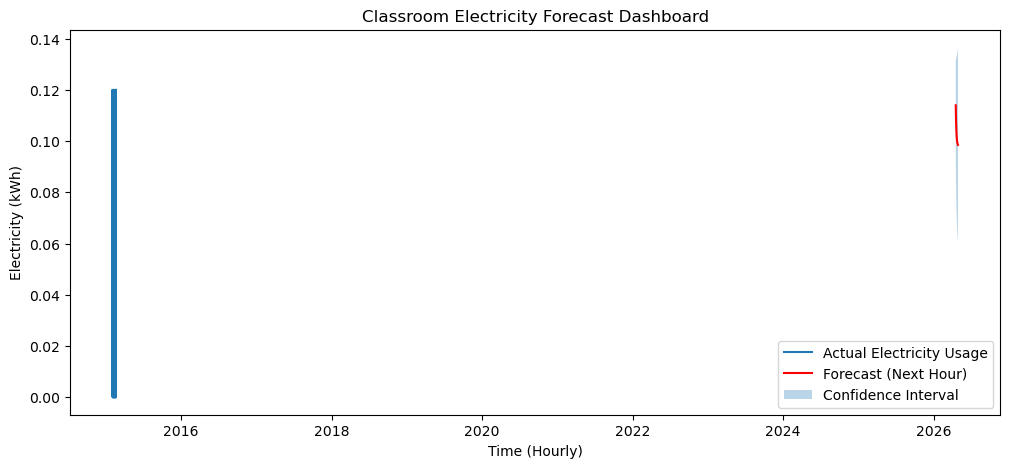

In [29]:
plt.figure(figsize=(12,5))

plt.plot(data['electricity'], label="Actual Electricity Usage")
plt.plot(predicted, label="Forecast (Next Hour)", color="red")

plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 alpha=0.3,
                 label="Confidence Interval")

plt.xlabel("Time (Hourly)")
plt.ylabel("Electricity (kWh)")
plt.title("Classroom Electricity Forecast Dashboard")
plt.legend()
plt.show()


In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
data = pd.read_csv(r"C:\Users\SHREYA\Downloads\archive (8)\Occupancy.csv")
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)
data = data.asfreq('H')
data['electricity'] = data['Occupancy'] * 0.12


C:\Users\SHREYA\AppData\Local\Temp\ipykernel_21104\2596910477.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data = data.asfreq('H')


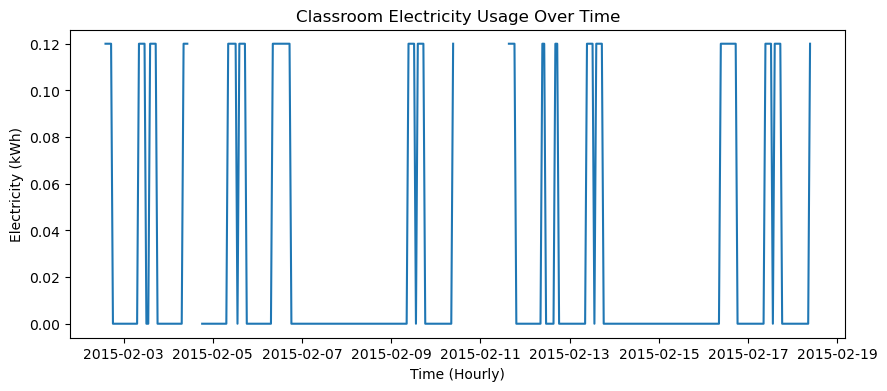

In [54]:
plt.figure(figsize=(10,4))
plt.plot(data['electricity'])
plt.title("Classroom Electricity Usage Over Time")
plt.xlabel("Time (Hourly)")
plt.ylabel("Electricity (kWh)")
plt.show()


In [56]:
model = ARIMA(data['electricity'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:            electricity   No. Observations:                  380
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 661.191
Date:                Thu, 22 Jan 2026   AIC                          -1316.382
Time:                        11:01:01   BIC                          -1304.569
Sample:                    02-02-2015   HQIC                         -1311.694
                         - 02-18-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7335      0.060     12.214      0.000       0.616       0.851
ma.L1         -0.9999      1.514     -0.660      0.509      -3.968       1.968
sigma2         0.0012      0.002      0.636      0.5

C:\Users\SHREYA\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [64]:
forecast_steps = 12

forecast = model_fit.get_forecast(steps=forecast_steps)

predicted = forecast.predicted_mean
conf_int = forecast.conf_int()
future_index = pd.date_range(
    start=data.index[-1] + pd.Timedelta(hours=1),
    periods=forecast_steps,
    freq='H'
)

predicted.index = future_index
conf_int.index = future_index


C:\Users\SHREYA\AppData\Local\Temp\ipykernel_21104\3563943549.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_index = pd.date_range(


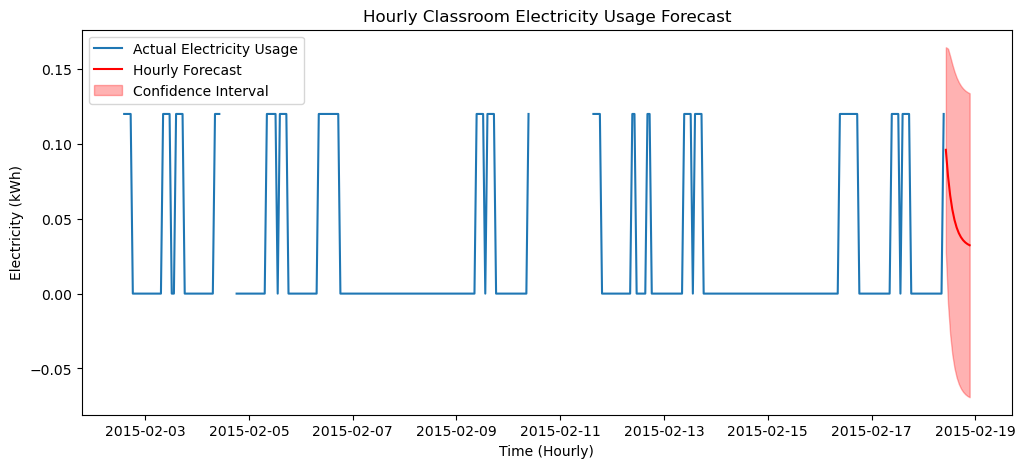

In [66]:
plt.figure(figsize=(12,5))

plt.plot(data['electricity'], label="Actual Electricity Usage")
plt.plot(predicted, label="Hourly Forecast", color="red")

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='red',
    alpha=0.3,
    label="Confidence Interval"
)

plt.xlabel("Time (Hourly)")
plt.ylabel("Electricity (kWh)")
plt.title("Hourly Classroom Electricity Usage Forecast")
plt.legend()
plt.show()
